# Winter Airbnb Pricing Analysis
## Comparing listings between Skaneateles Lake and Canandaigua Lake, NY

This notebook presents the results of a Random Forest analysis examining what drives winter Airbnb pricing in two Finger Lakes regions over three winter seasons (2022–2025).

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns

matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['savefig.transparent'] = False
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor'] = 'white'

rf_sk = pd.read_csv('../results/rf_results_skaneateles.csv')
rf_ca = pd.read_csv('../results/rf_results_canandaigua.csv')
importance_sk = pd.read_csv('../results/full_model_importance_skaneateles.csv')
importance_ca = pd.read_csv('../results/full_model_importance_canandaigua.csv')
merged_sk = pd.read_csv('../data/merged_skaneateles.csv')
merged_ca = pd.read_csv('../data/merged_canandaigua.csv')


## 1. Model Performance Summary

In [40]:
print('Skaneateles listings:', len(rf_sk))
print('Canandaigua listings:', len(rf_ca))

summary = pd.DataFrame({
    'Region': ['Skaneateles Lake', 'Canandaigua Lake'],
    'Valid Listings': [len(rf_sk), len(rf_ca)],
    'Mean R²': [rf_sk['r2'].mean().round(3), rf_ca['r2'].mean().round(3)],
    'Median R²': [rf_sk['r2'].median().round(3), rf_ca['r2'].median().round(3)],
    'Mean MAE ($)': [rf_sk['mae'].mean().round(2), rf_ca['mae'].mean().round(2)]
})
print(summary.to_string(index=False))

Skaneateles listings: 90
Canandaigua listings: 203
          Region  Valid Listings  Mean R²  Median R²  Mean MAE ($)
Skaneateles Lake              90    0.546      0.610         18.11
Canandaigua Lake             203    0.436      0.473         13.65


## 2. R² Distribution — Single Listing Models

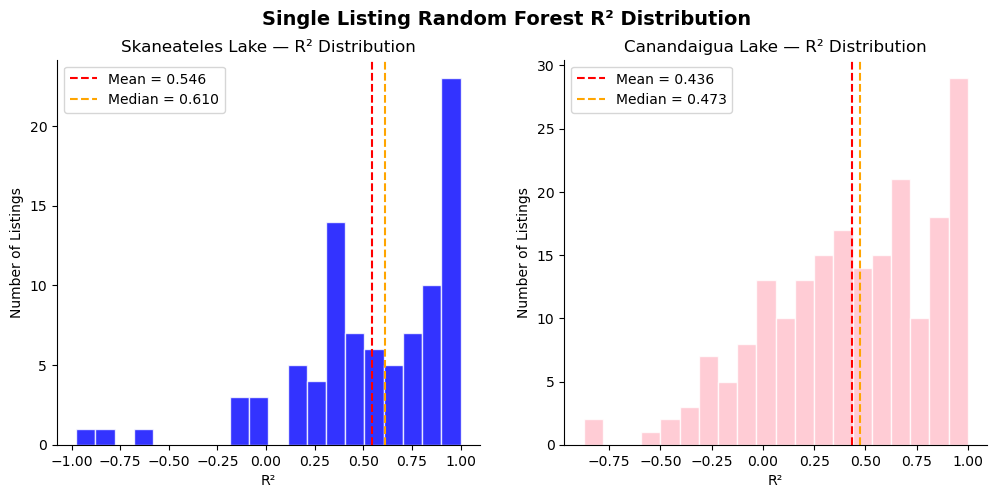

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(rf_sk['r2'], bins=20, color='blue', edgecolor='white', alpha=0.8)
axes[0].axvline(rf_sk['r2'].mean(), color='red', linestyle='--', label=f'Mean = {rf_sk["r2"].mean():.3f}')
axes[0].axvline(rf_sk['r2'].median(), color='orange', linestyle='--', label=f'Median = {rf_sk["r2"].median():.3f}')
axes[0].set_title('Skaneateles Lake — R² Distribution')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Number of Listings')
axes[0].legend()

axes[1].hist(rf_ca['r2'], bins=20, color='pink', edgecolor='white', alpha=0.8)
axes[1].axvline(rf_ca['r2'].mean(), color='red', linestyle='--', label=f'Mean = {rf_ca["r2"].mean():.3f}')
axes[1].axvline(rf_ca['r2'].median(), color='orange', linestyle='--', label=f'Median = {rf_ca["r2"].median():.3f}')
axes[1].set_title('Canandaigua Lake — R² Distribution')
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Number of Listings')
axes[1].legend()

plt.suptitle('Single Listing Random Forest R² Distribution', fontsize=14, fontweight='bold')
plt.savefig('../results/r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Importance — Full Model (Normalized Prices)


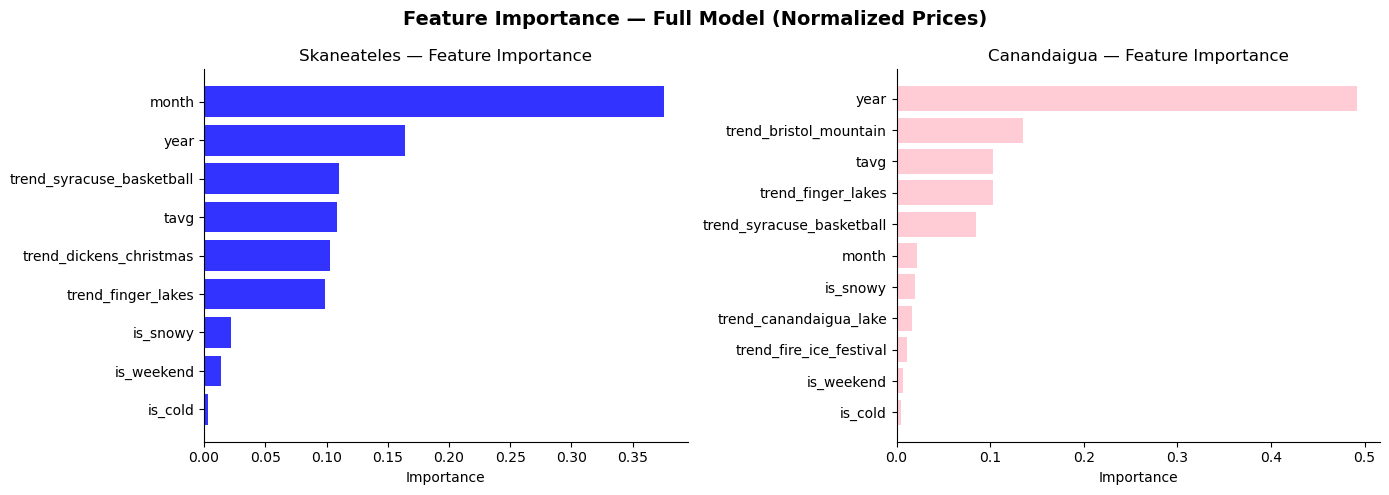

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skaneateles
imp_sk = importance_sk.sort_values('importance', ascending=True)
axes[0].barh(imp_sk['feature'], imp_sk['importance'], color='blue', alpha=0.8)
axes[0].set_title('Skaneateles — Feature Importance')
axes[0].set_xlabel('Importance')

# Canandaigua
imp_ca = importance_ca.sort_values('importance', ascending=True)
axes[1].barh(imp_ca['feature'], imp_ca['importance'], color='pink', alpha=0.8)
axes[1].set_title('Canandaigua — Feature Importance')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance — Full Model (Normalized Prices)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Average Price by Month

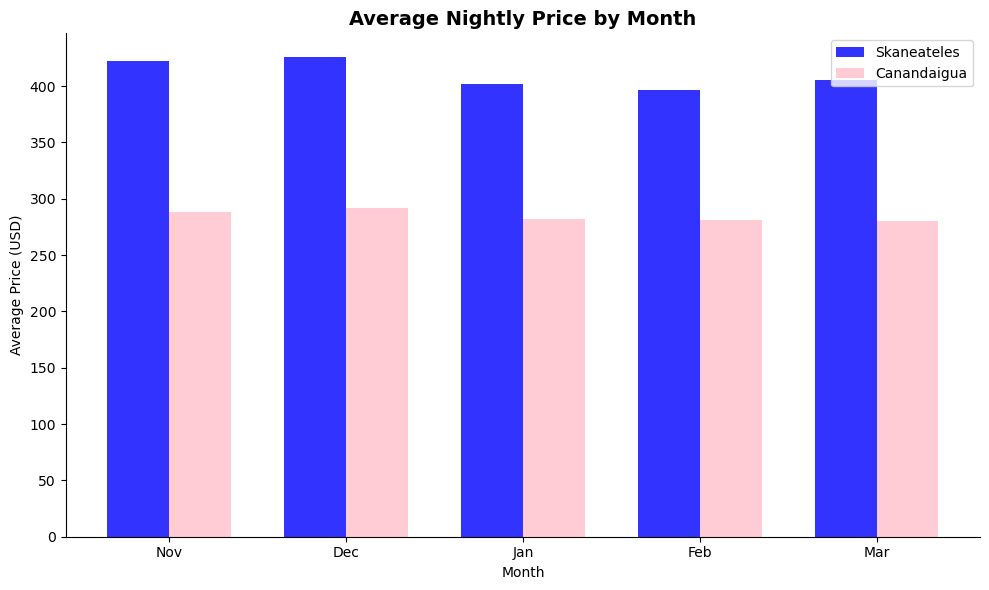

In [43]:
month_names = {11: 'Nov', 12: 'Dec', 1: 'Jan', 2: 'Feb', 3: 'Mar'}
months_order = [11, 12, 1, 2, 3]

# Compute monthly averages
sk_monthly = merged_sk.groupby('month')['price_usd'].mean()
ca_monthly = merged_ca.groupby('month')['price_usd'].mean()

x = np.arange(len(month_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
sk_vals = [sk_monthly.get(m, 0) for m in months_order]
ca_vals = [ca_monthly.get(m, 0) for m in months_order]

bars1 = ax.bar(x - width/2, sk_vals, width, label='Skaneateles', color='blue', alpha=0.8)
bars2 = ax.bar(x + width/2, ca_vals, width, label='Canandaigua', color='pink', alpha=0.8)

ax.set_xlabel('Month')
ax.set_ylabel('Average Price (USD)')
ax.set_title('Average Nightly Price by Month', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([month_names[m] for m in months_order])
ax.legend()

plt.tight_layout()
plt.savefig('../results/price_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Price vs. Temperature

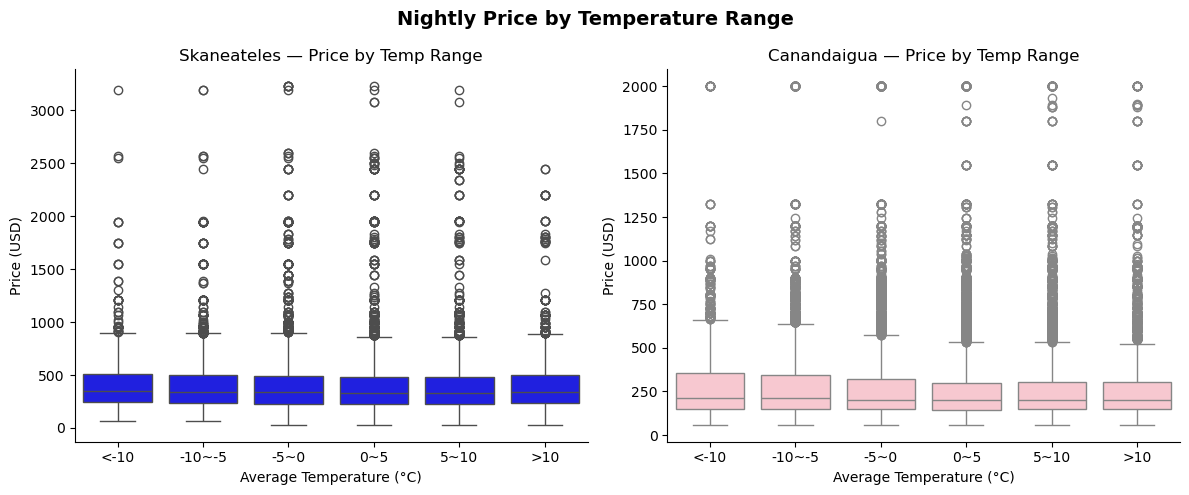

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for df, ax, color, title in [
    (merged_sk, axes[0], 'blue', 'Skaneateles'),
    (merged_ca, axes[1], 'pink',     'Canandaigua')
]:
    df = df.copy()
    df['temp_bin'] = pd.cut(df['tavg'],
                            bins=[-20, -10, -5, 0, 5, 10, 20],
                            labels=['<-10', '-10~-5', '-5~0', '0~5', '5~10', '>10'])
    sns.boxplot(data=df, x='temp_bin', y='price_usd',
                color=color, ax=ax)
    ax.set_title(f'{title} — Price by Temp Range')
    ax.set_xlabel('Average Temperature (°C)')
    ax.set_ylabel('Price (USD)')

plt.suptitle('Nightly Price by Temperature Range', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/price_vs_temperature.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

## 6. Dickens Christmas Trend vs. Average Price (Skaneateles)

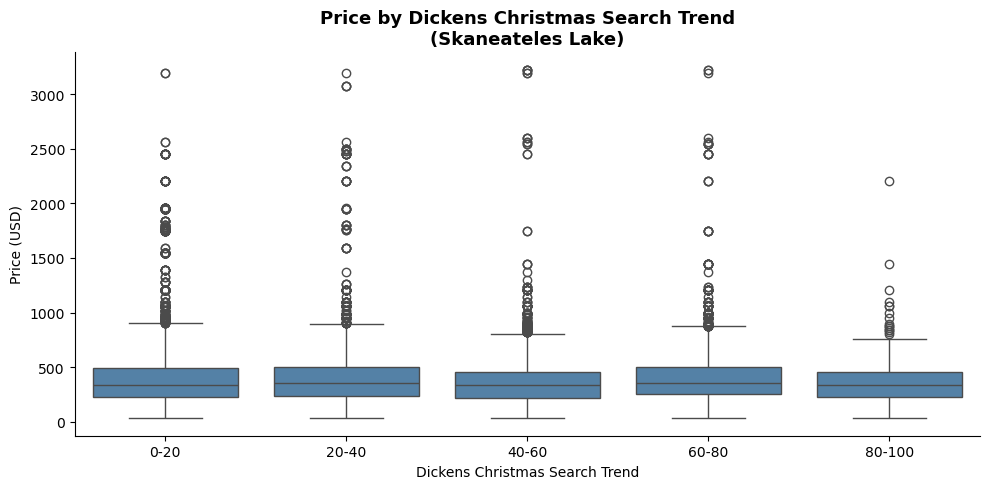

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

merged_sk2 = merged_sk.copy()
merged_sk2['trend_bin'] = pd.cut(merged_sk2['trend_dickens_christmas'],
                                  bins=[0, 20, 40, 60, 80, 100],
                                  labels=['0-20', '20-40', '40-60', '60-80', '80-100'],
                                  include_lowest=True)

sns.boxplot(data=merged_sk2, x='trend_bin', y='price_usd', color='steelblue', ax=ax)
ax.set_xlabel('Dickens Christmas Search Trend')
ax.set_ylabel('Price (USD)')
ax.set_title('Price by Dickens Christmas Search Trend\n(Skaneateles Lake)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/dickens_vs_price.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

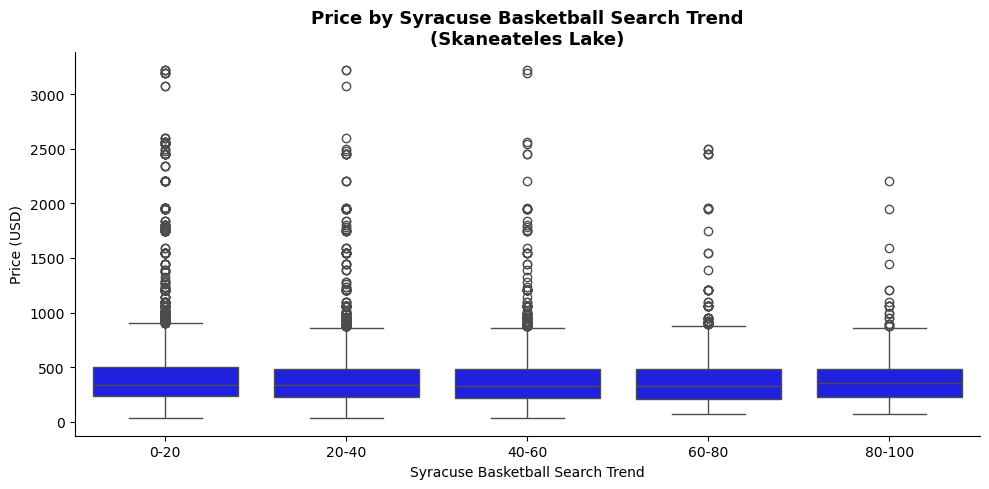

In [46]:
# --- Syracuse Basketball Trend vs Price (Skaneateles) ---
merged_sk5 = merged_sk.copy()
merged_sk5['basketball_bin'] = pd.cut(merged_sk5['trend_syracuse_basketball'],
                                       bins=[0, 20, 40, 60, 80, 100],
                                       labels=['0-20', '20-40', '40-60', '60-80', '80-100'],
                                       include_lowest=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=merged_sk5, x='basketball_bin', y='price_usd', color='blue', ax=ax)
ax.set_xlabel('Syracuse Basketball Search Trend')
ax.set_ylabel('Price (USD)')
ax.set_title('Price by Syracuse Basketball Search Trend\n(Skaneateles Lake)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/basketball_vs_price.png', dpi=150,
            bbox_inches='tight', transparent=True)
plt.show()

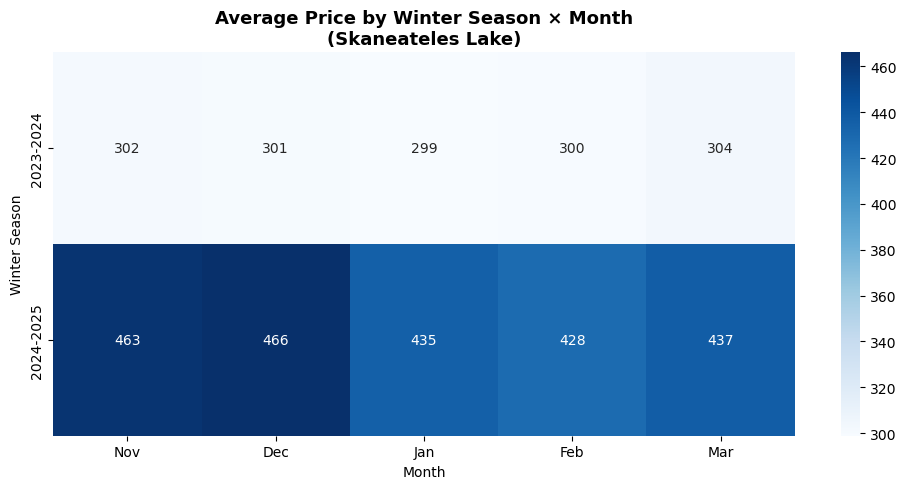

In [49]:
merged_sk4 = merged_sk.copy()
merged_sk4['winter'] = merged_sk4.apply(
    lambda row: str(int(row['year'])) + '-' + str(int(row['year'])+1)
    if row['month'] in [11, 12]
    else str(int(row['year'])-1) + '-' + str(int(row['year'])),
    axis=1
)

pivot3 = merged_sk4.groupby(['winter', 'month'])['price_usd'].mean().unstack()
pivot3.columns = ['Jan', 'Feb', 'Mar', 'Nov', 'Dec']
pivot3 = pivot3[['Nov', 'Dec', 'Jan', 'Feb', 'Mar']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot3, annot=True, fmt='.0f', cmap='Blues', ax=ax)
ax.set_title('Average Price by Winter Season × Month\n(Skaneateles Lake)',
             fontsize=13, fontweight='bold')

ax.set_xlabel('Month')
ax.set_ylabel('Winter Season')

plt.tight_layout()
plt.savefig('../results/heatmap_winter_month.png', dpi=150, bbox_inches='tight')
plt.show()

**Note:** Data collection was attempted for the 2022–2023 winter season,
but the API returned no results for that period, confirming that historical
pricing data is unavailable beyond approximately 2 years. The dataset therefore
covers two complete winter seasons: 2023–2024 and 2024–2025.